# CANDLE/FCIS - Counterfactual Simulation

**What-if analysis**: "What would have happened if X was different?"

Use cases:
- Historical event replay
- Trading decision evaluation
- Scenario stress testing

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from counterfactual import CounterfactualSimulator
from causal_inference import CausalInferenceEngine
from visualization import CANDLEVisualizer

viz = CANDLEVisualizer('../results/figures')

In [2]:
# Cell removed - duplicate of cell above
# Load data
data = pd.read_csv('../data/processed/merged_data.csv', index_col=0, parse_dates=True)

# Load graph (try multiple formats)
import pickle
try:
    with open('../data/processed/causal_graph.pkl', 'rb') as f:
        graph = pickle.load(f)
    print(f"✓ Loaded graph with {len(graph.nodes)} nodes")
    
    # Fit inference engine to get models
    engine = CausalInferenceEngine()
    engine.fit(data, graph)
    
    print(f"✓ Fitted {len(engine.models)} outcome models")
    
except Exception as e:
    print(f"⚠ Using synthetic graph: {e}")
    # Create simple graph for demo
    graph = nx.DiGraph()
    for col in data.columns:
        graph.add_node(col)
    engine = None
    

✓ Loaded graph with 25 nodes
✓ Fitted 23 outcome models


## 2. Initialize Counterfactual Simulator

In [3]:
if engine is not None:
    sim = CounterfactualSimulator(
        causal_graph=graph,
        outcome_models=engine.models,
        data=data
    )
    print("✓ Counterfactual simulator initialized")
else:
    print("⚠ Skipping - no models available")
    sim = None

✓ Counterfactual simulator initialized


## 3. Scenario 1: What if sentiment was very positive?

In [4]:
if sim is not None and 'sentiment_mean' in data.columns:
    # Pick a recent date
    target_date = data.index[-20]
    
    # Scenario: sentiment = +2.0 (very positive)
    result = sim.simulate_intervention(
        intervention={'sentiment_mean': 2.0},
        target_date=target_date
    )
    
    print(f"\nDate: {target_date.strftime('%Y-%m-%d')}")
    print(f"Intervention: sentiment_mean = 2.0 (very positive)")
    print(f"\nFactual values:")
    for var, val in list(result['factual'].items())[:5]:
        print(f"  {var}: {val:.4f}")
    
    print(f"\nCounterfactual values:")
    for var, val in list(result['counterfactual'].items())[:5]:
        print(f"  {var}: {val:.4f}")
    
    print(f"\nCausal Impact: {result['comparison']['causal_impact']:.4f}")
    print(f"Most affected: {result['comparison']['most_affected_variable']}")


Date: 2025-12-03
Intervention: sentiment_mean = 2.0 (very positive)

Factual values:
  ADANIENT: -0.0225
  BAJFINANCE: -0.0040
  HDFCBANK: 0.0108
  ICICIBANK: 0.0134
  INFY: 0.0113

Counterfactual values:
  ADANIENT: -0.0225
  BAJFINANCE: -0.0040
  HDFCBANK: 0.0010
  ICICIBANK: -0.0002
  INFY: 0.0004

Causal Impact: nan
Most affected: WIPRO


## 4. Visualize Factual vs Counterfactual

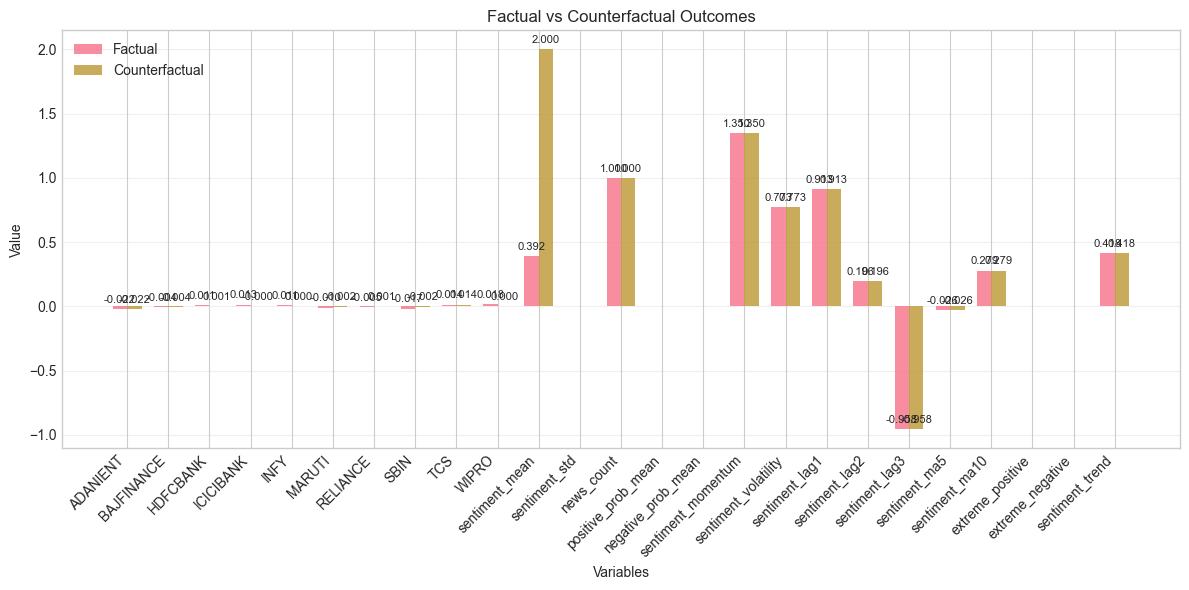

In [5]:
if sim is not None:
    fig = viz.plot_counterfactual_comparison(
        factual=result['factual'],
        counterfactual=result['counterfactual'],
        intervention={'sentiment_mean': 2.0},
        save_path='../results/figures/counterfactual_comparison.png'
    )
    plt.show()

## 5. Scenario 2: What-if Analysis (Range of Values)


What-if analysis for sentiment → ADANIENT:
   intervention_value  ADANIENT_factual  ADANIENT_counterfactual  \
0           -2.000000          0.011225                 0.011225   
1           -1.714286          0.011225                 0.011225   
2           -1.428571          0.011225                 0.011225   
3           -1.142857          0.011225                 0.011225   
4           -0.857143          0.011225                 0.011225   

   ADANIENT_difference  
0                  0.0  
1                  0.0  
2                  0.0  
3                  0.0  
4                  0.0  


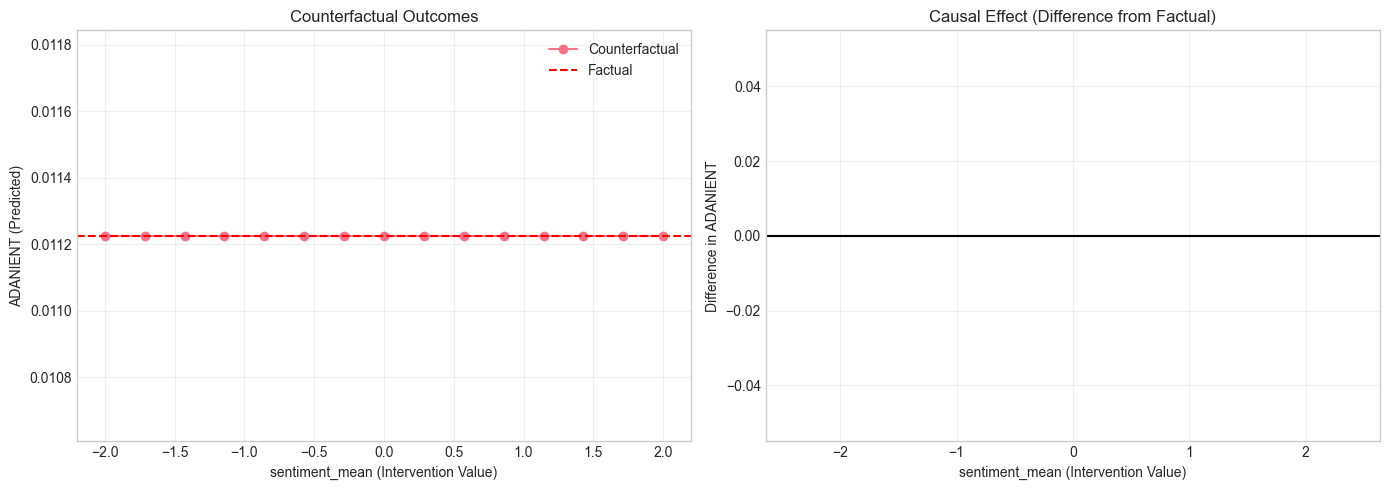

In [6]:
if sim is not None and 'sentiment_mean' in data.columns:
    # Get stock columns
    stock_cols = [c for c in data.columns if 'sentiment' not in c and c != 'news_count']
    
    if stock_cols:
        outcome_var = stock_cols[0]
        
        # Run what-if analysis
        what_if = sim.what_if_analysis(
            variable='sentiment_mean',
            value_range=(-2.0, 2.0),
            n_scenarios=15,
            outcome_vars=[outcome_var]
        )
        
        print(f"\nWhat-if analysis for sentiment → {outcome_var}:")
        print(what_if[['intervention_value', f'{outcome_var}_factual', 
                       f'{outcome_var}_counterfactual', f'{outcome_var}_difference']].head())
        
        # Visualize
        fig = viz.plot_what_if_analysis(
            what_if,
            intervention_var='sentiment_mean',
            outcome_var=outcome_var,
            save_path='../results/figures/what_if_analysis.png'
        )
        plt.show()

## 6. Scenario 3: Batch Counterfactual Scenarios

In [7]:
if sim is not None:
    # Define multiple scenarios
    scenarios = [
        {'sentiment_mean': 1.5},
        {'sentiment_mean': -1.5},
        {'sentiment_mean': 0.0},  # Neutral
    ]
    
    # Add stock interventions if available
    stock_cols = [c for c in data.columns if 'sentiment' not in c and c != 'news_count']
    if stock_cols:
        scenarios.append({stock_cols[0]: 0.03})  # +3% return
        scenarios.append({stock_cols[0]: -0.03})  # -3% return
    
    print(f"Running {len(scenarios)} counterfactual scenarios...")
    
    batch_results = sim.batch_counterfactuals(scenarios)
    
    print("\nScenario Results:")
    print(batch_results[['scenario_id', 'intervention', 'causal_impact', 'most_affected']].to_string())
    
    batch_results.to_csv('../results/counterfactual_batch.csv', index=False)

Running 5 counterfactual scenarios...

Scenario Results:
   scenario_id              intervention  causal_impact most_affected
0            0   {'sentiment_mean': 1.5}            NaN      RELIANCE
1            1  {'sentiment_mean': -1.5}            NaN      RELIANCE
2            2   {'sentiment_mean': 0.0}            NaN      RELIANCE
3            3        {'ADANIENT': 0.03}            NaN      RELIANCE
4            4       {'ADANIENT': -0.03}            NaN      RELIANCE


## 7. Hindsight Analysis: Evaluate Past Decisions

In [8]:
if sim is not None and stock_cols:
    # Pick a historical date
    hist_date = data.index[100]
    target = stock_cols[0]
    
    hindsight = sim.hindsight_analysis(
        target_var=target,
        target_date=hist_date.strftime('%Y-%m-%d'),
        alternative_value=0.05  # What if return was +5% instead?
    )
    
    print(f"\nHindsight Analysis for {hist_date.strftime('%Y-%m-%d')}:")
    print(f"  Variable: {target}")
    print(f"  Factual value: {hindsight['factual_value']:.4f}")
    print(f"  Alternative: {hindsight['alternative_value']:.4f}")
    print(f"  Better outcome: {hindsight['better_outcome']}")
    
    if hindsight['return_difference'] > 0:
        print(f"  ✓ Alternative would have been BETTER by {hindsight['return_difference']:.4f}")
    else:
        print(f"  ✗ Alternative would have been WORSE by {abs(hindsight['return_difference']):.4f}")


Hindsight Analysis for 2016-04-10:
  Variable: ADANIENT
  Factual value: 0.0318
  Alternative: 0.0500
  Better outcome: False
  ✗ Alternative would have been WORSE by 0.0000


## Summary

This notebook demonstrated counterfactual simulation:
1. Single intervention: "What if sentiment = +2.0?"
2. Range analysis: What-if across multiple values
3. Batch scenarios: Multiple interventions at once
4. Hindsight: Evaluating past decisions

**Output files**:
- `results/counterfactual_batch.csv`
- `results/figures/counterfactual_comparison.png`
- `results/figures/what_if_analysis.png`